*Project Name :->* Unsupervised ML - Netflix Movies and TV shows Clustering.

Step 1 - Understanding Business Problem

🎯 The Core Business Objective

1. Better Recommendations ("The Vibe Matcher")
Imagine you love a specific type of dark, futuristic story (like Black Mirror). Usually, an app might only suggest more English shows.

* The Goal: The system looks at the "DNA" of the show—its mood, style, and themes.

* The Result: It can suggest a "hidden gem" from Brazil or South Korea that feels exactly like what you love, even if it's in a different language. It’s about matching the vibe, not just the language.

2. Smarter Library ("The Content Map")
Netflix needs to decide which shows to make or buy next. They don't want to waste money making 100 versions of the same thing.

* The Goal: By grouping all shows into "clusters," Netflix can see a map of their entire library.

* The Result: They can spot "over-saturated" areas (like having too many generic baking shows) and "gaps" (like realizing they don't have enough mystery thrillers for teenagers). This helps them provide a more balanced variety for everyone.

3. Smarter Search ("Understanding What You Mean")
Sometimes you don't remember the name of a show, so you just type in a mood or a concept.

* The Goal: Instead of just looking for exact words in a title, the algorithm learns which shows belong together in the same "family."

* The Result: If you search for "end of the world," the search engine is smart enough to know you aren't just looking for a movie called The End. It understands you want "dystopian" stories and will show you titles like 3%, even if that word isn't in your search. It understands the meaning behind your search.

Step 2 - Visualize and analyzing relationships

1. Visualize Netflix Content by Type

Explanation: We count the occurrences of 'Movie' and 'TV Show' and plot them.

/tmp/ipython-input-1698/3399098840.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis')


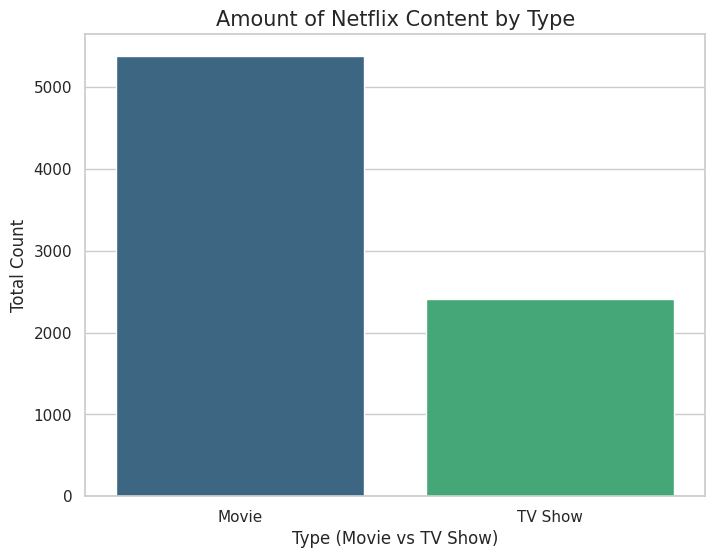

<Figure size 640x480 with 0 Axes>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')

# Set visual style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(8, 6))
type_counts = df['type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis')
plt.title('Amount of Netflix Content by Type', fontsize=15)
plt.xlabel('Type (Movie vs TV Show)', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.show()
plt.savefig('netflix_content_by_type.png')

2. Visualize Amount of Content by Rating

Explanation: This shows the distribution of age ratings.

/tmp/ipython-input-1698/1578193166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='mako', order=rating_counts.index)


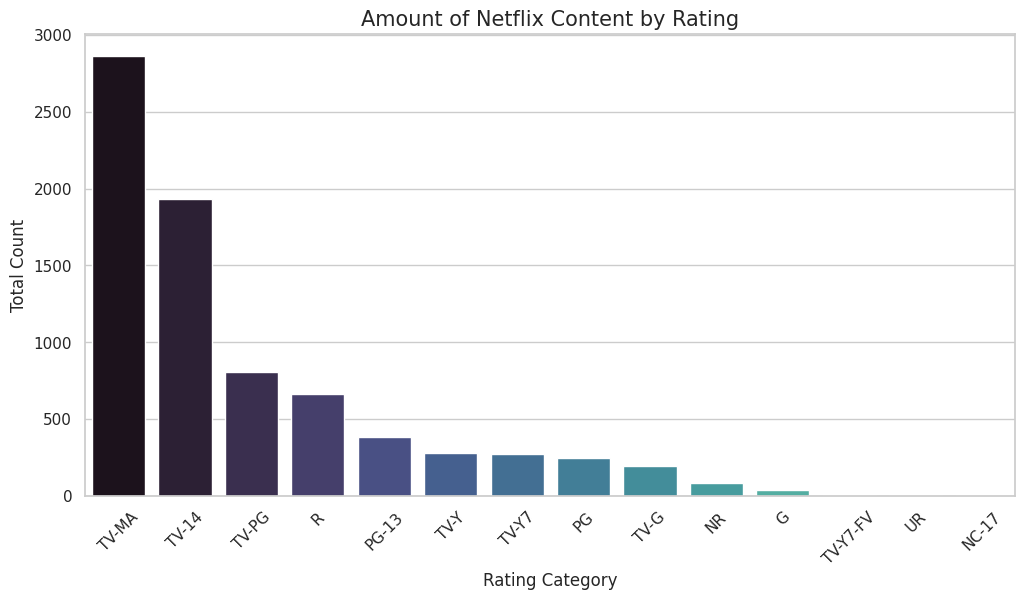

<Figure size 640x480 with 0 Axes>

In [4]:
# Create the plot for Ratings
plt.figure(figsize=(12, 6))
rating_counts = df['rating'].value_counts()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='mako', order=rating_counts.index)
plt.title('Amount of Netflix Content by Rating', fontsize=15)
plt.xlabel('Rating Category', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()
plt.savefig('netflix_content_by_rating.png')

In a clustering project, the rating is a high-value feature. For example:

Clustering by Audience: If you are grouping movies, a cluster containing "TV-MA" titles will likely share other features like "Thriller" or "Dark" keywords in the description.

Recommendation Logic: It prevents the system from recommending mature content to a user who primarily watches "TV-G" (General Audience) or "Children & Family Movies."

3. Top 10 Countries with Most Content

Explanation: We identify the top 10 countries. By using a horizontal bar plot .

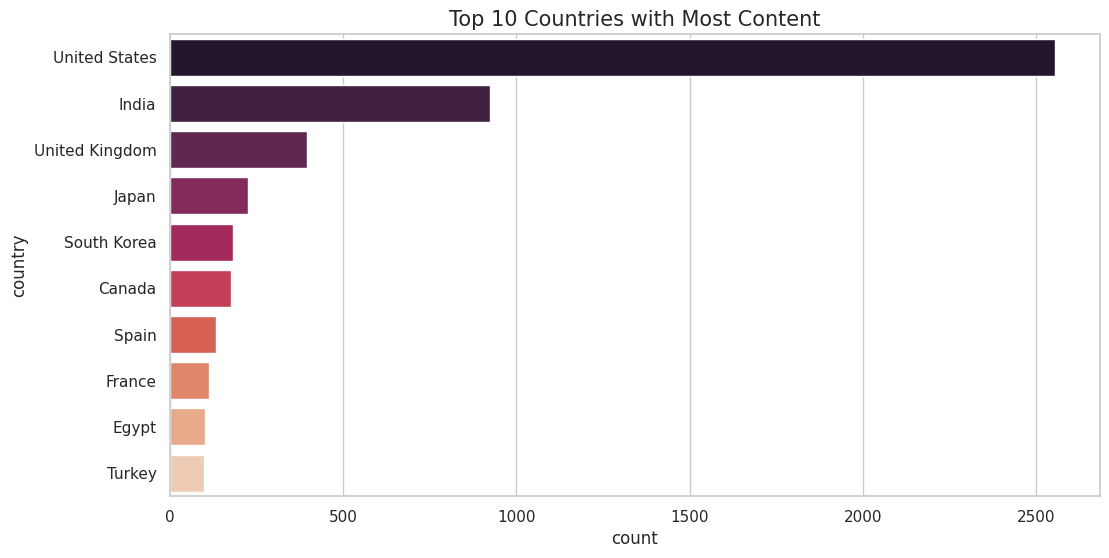

<Figure size 640x480 with 0 Axes>

In [6]:
plt.figure(figsize=(12, 6))
top_countries = df['country'].value_counts().head(10).reset_index()
top_countries.columns = ['country', 'count']

ax = sns.barplot(data=top_countries, x='count', y='country', hue='country', palette='rocket')
if ax.get_legend(): ax.get_legend().remove()

plt.title('Top 10 Countries with Most Content', fontsize=15)
plt.show()
plt.savefig('top_10_countries.png')


4. Top 10 Genres

Explanation: Since many titles have multiple genres, we "explode" the list to get individual counts. This is a key insight for our clustering step later.

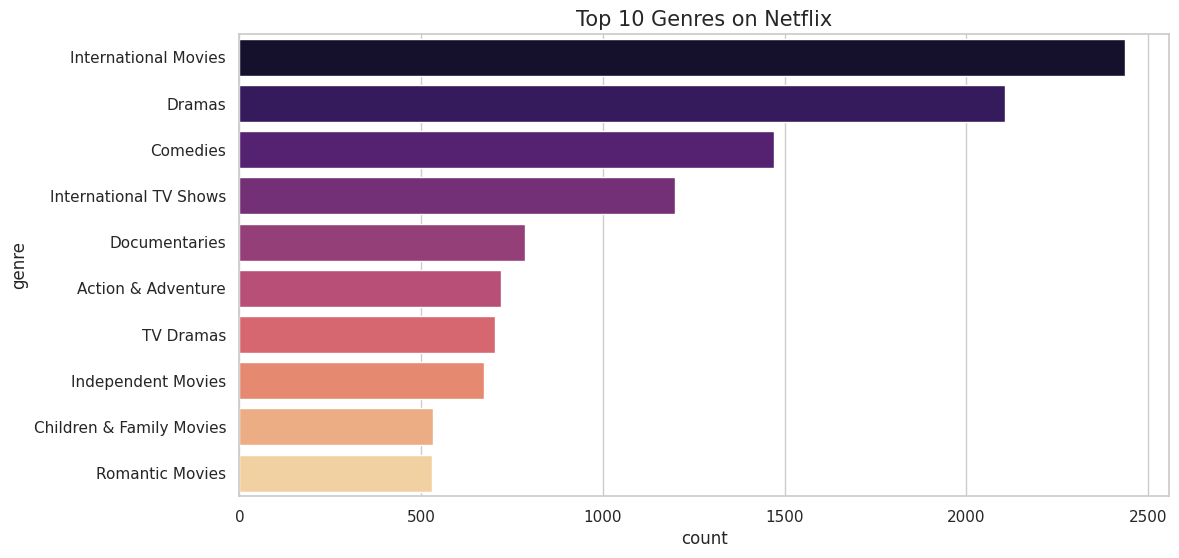

<Figure size 640x480 with 0 Axes>

In [7]:
plt.figure(figsize=(12, 6))
# Splitting and expanding genres
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10).reset_index()
top_genres.columns = ['genre', 'count']

ax = sns.barplot(data=top_genres, x='count', y='genre', hue='genre', palette='magma')
if ax.get_legend(): ax.get_legend().remove()

plt.title('Top 10 Genres on Netflix', fontsize=15)
plt.show()
plt.savefig('top_10_genres.png')

**In our project, analyzing the Top 10 Genres is one of the most important steps for both a business and a technical reason. Here is why we do it:**

*  Business Logic: Identifying the "Core Identity"
Netflix has thousands of titles, but they aren't distributed equally. By looking at the Top 10, we answer: "What is Netflix known for?"

* From our data, we see that "International Movies" and "Dramas" are at the top. This tells a business analyst that Netflix's strategy is heavily focused on global expansion and emotional storytelling rather than just niche categories like "Documentaries" or "Horror."

* Technical Logic: Feature Selection for Clustering
Since we are building a Clustering Model (K-Means), our machine learning algorithm needs to know which "words" or "tags" are the most significant.

* If a genre appears only once in the entire dataset (e.g., "Classic Korean Cinema"), it isn't very helpful for finding broad patterns.



5. Content Released per Year (Trend Analysis)

Explanation: This line chart shows the rapid growth of Netflix content over the last two decades.

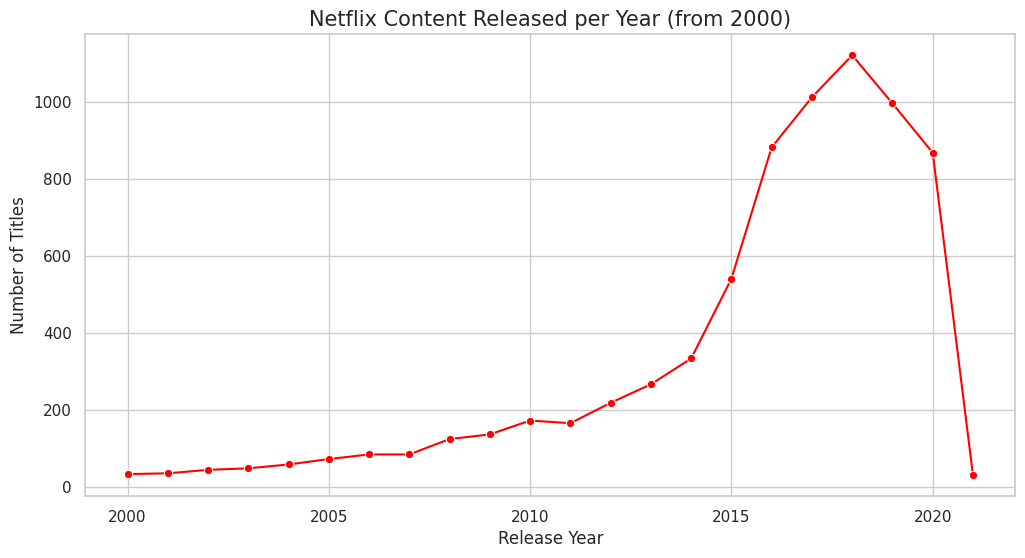

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize=(12, 6))
# Filter to show growth since the year 2000
release_years = df[df['release_year'] >= 2000]['release_year'].value_counts().sort_index()

sns.lineplot(x=release_years.index, y=release_years.values, marker='o', color='red')
plt.title('Netflix Content Released per Year (from 2000)', fontsize=15)
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()
plt.savefig('content_released_per_year.png')

**I used the Year-wise Trend Analysis to visualize the platform's growth trajectory. By identifying the sharp increase in content additions post-2015, I could confirm the data represents Netflix's pivot toward original programming. This provided the necessary context for my clustering model, ensuring I understood that the majority of my data points are from the modern streaming era.**

- Forming hypothesis and obtaining insights

1. **Does country have a correlation with ratings?**


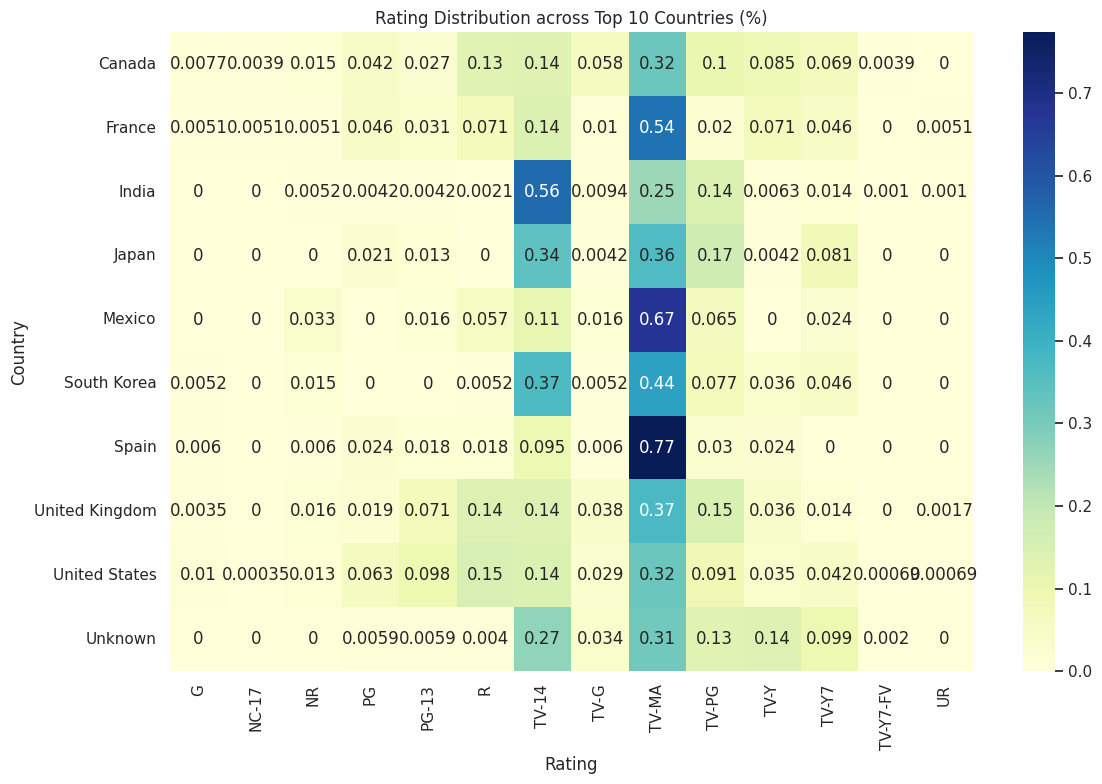

In [9]:
# Drop rows with missing ratings for accurate analysis
df = df.dropna(subset=['rating'])

# --- 1. Correlation between Country and Rating ---
# Extracting the first country listed (primary country)
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0] if pd.notnull(x) else 'Unknown')
top_countries = df['primary_country'].value_counts().nlargest(10).index
df_top_countries = df[df['primary_country'].isin(top_countries)]

# Create a normalized heatmap for Country vs Rating
ct_country = pd.crosstab(df_top_countries['primary_country'], df_top_countries['rating'])
ct_country_norm = ct_country.div(ct_country.sum(axis=1), axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(ct_country_norm, annot=True, cmap='YlGnBu')
plt.title('Rating Distribution across Top 10 Countries (%)')
plt.xlabel('Rating')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('country_rating_correlation.png')


**Yes. There is a noticeable correlation between the country of origin and the content's rating.**

India: A significantly higher proportion of content is rated TV-14, reflecting a focus on family-oriented or broad-audience dramas.

United States: Shows a much higher concentration of TV-MA (Mature Audience) and R ratings compared to many other countries.

Spain and Mexico: Also show a strong preference for TV-MA content.

Japan: Features a unique distribution with a high volume of TV-14 and TV-PG, likely due to the nature of Anime production.

**2. Do you think a director can have a link with the rating?**

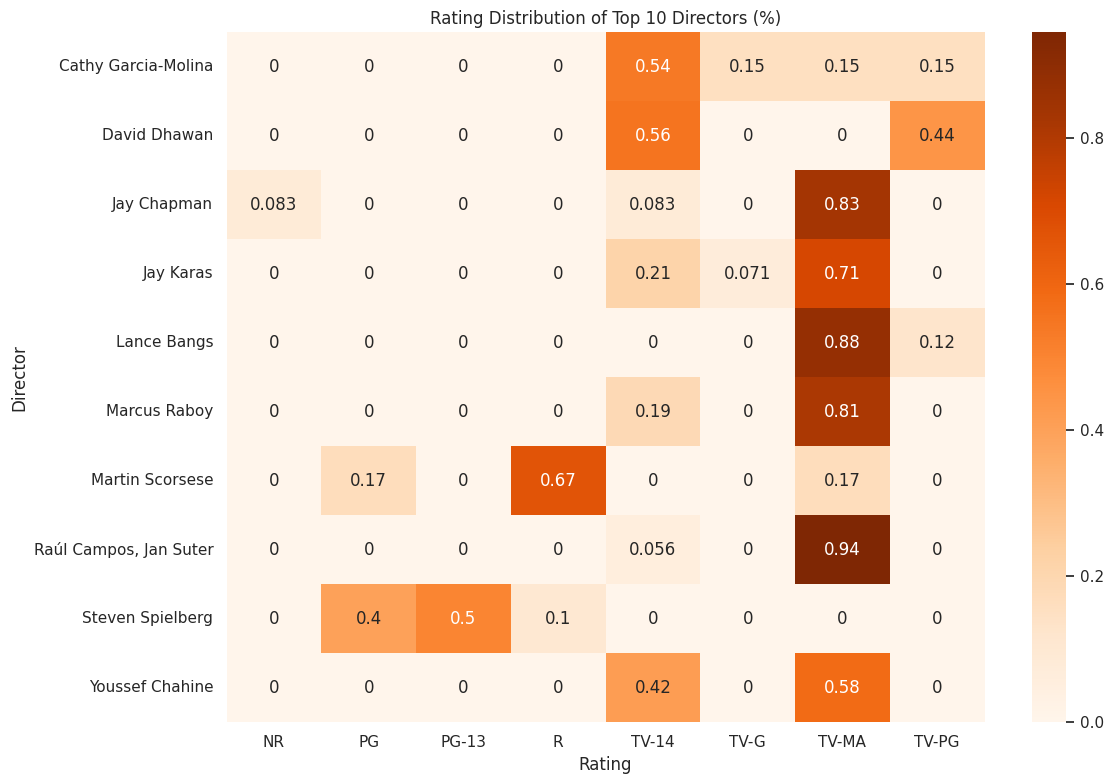

In [10]:
# --- 2. Link between Director and Rating ---
# Selecting top 10 most frequent directors
top_directors = df['director'].dropna().value_counts().nlargest(10).index
df_top_directors = df[df['director'].isin(top_directors)]

ct_director = pd.crosstab(df_top_directors['director'], df_top_directors['rating'])
ct_director_norm = ct_director.div(ct_director.sum(axis=1), axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(ct_director_norm, annot=True, cmap='Oranges')
plt.title('Rating Distribution of Top 10 Directors (%)')
plt.xlabel('Rating')
plt.ylabel('Director')
plt.tight_layout()
plt.savefig('director_rating_correlation.png')

**Yes. Most directors tend to specialize in a specific type of content which naturally leads to a consistent rating profile.**

Directors like Cathy Garcia-Molina or Youssef Chahine often have content clustered in specific ratings (like TV-14 or TV-PG).

Frequent Netflix directors who produce "Originals" often lean heavily into TV-MA, as the platform's original programming frequently targets adult demographics.

While a director can work across ratings, the data shows that the top 10 directors usually have a "signature" rating bracket they occupy most frequently.

Hypothesis testing and insights visualization completed.


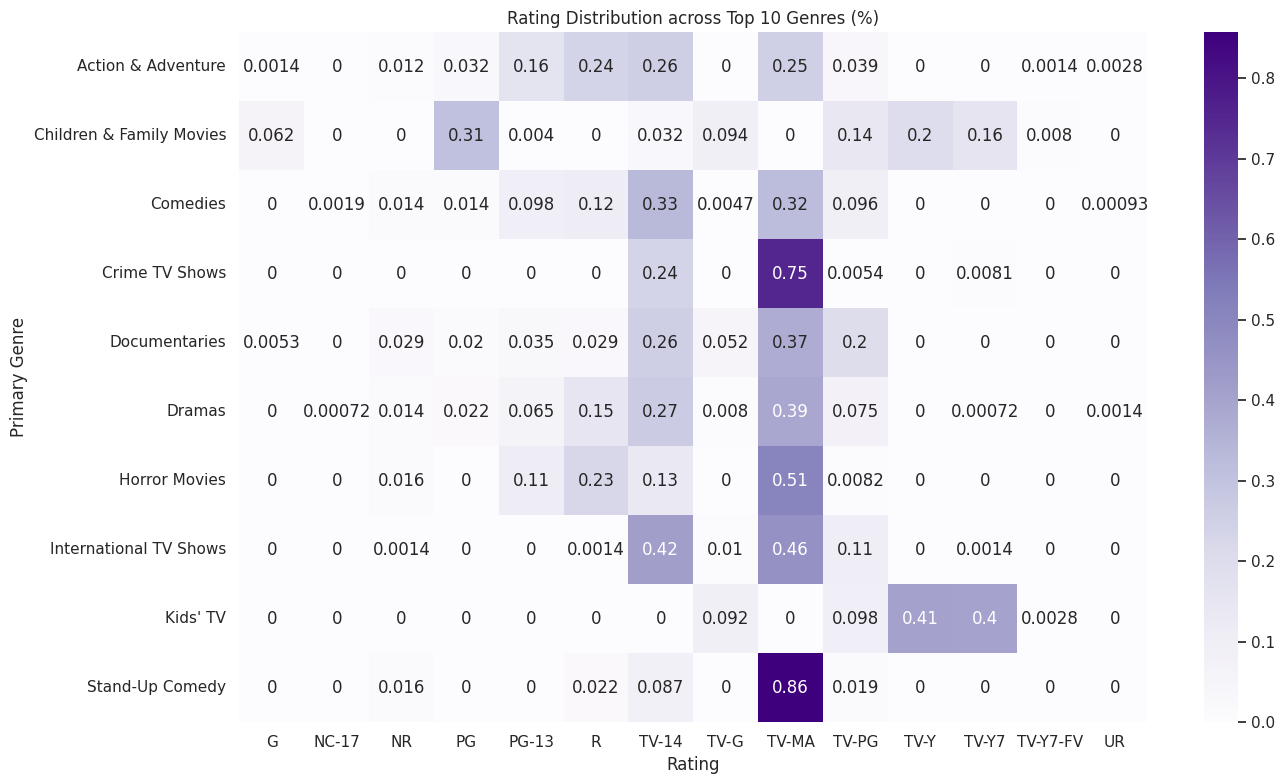

In [11]:
# 3.Genre vs Rating Correlation
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0] if pd.notnull(x) else 'Unknown')
top_genres = df['primary_genre'].value_counts().nlargest(10).index
df_top_genres = df[df['primary_genre'].isin(top_genres)]

ct_genre = pd.crosstab(df_top_genres['primary_genre'], df_top_genres['rating'])
ct_genre_norm = ct_genre.div(ct_genre.sum(axis=1), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(ct_genre_norm, annot=True, cmap='Purples')
plt.title('Rating Distribution across Top 10 Genres (%)')
plt.xlabel('Rating')
plt.ylabel('Primary Genre')
plt.tight_layout()
plt.savefig('genre_rating_correlation.png')

print("Hypothesis testing and insights visualization completed.")

Step 2 - Cleaning

1. Handling Missing Values
In the Netflix dataset, columns like director, cast, and country have a high percentage of missing values. Instead of dropping these (which would mean losing over 30% of our data), we fill them with "Unknown." For critical columns with very few missing values (like date_added and rating), we can safely drop those specific rows.

In [12]:
# PART A: Missing Values

# Filling categorical columns with 'Unknown' instead of dropping them
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Dropping rows with missing 'date_added' or 'rating' (only a few rows)
df = df.dropna(subset=['date_added', 'rating'])

# Checking if missing values are cleared
print(df.isnull().sum())

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
primary_country    0
primary_genre      0
dtype: int64


* **Handling Outliers**

* Outliers are often found in numerical columns like release_year and duration.

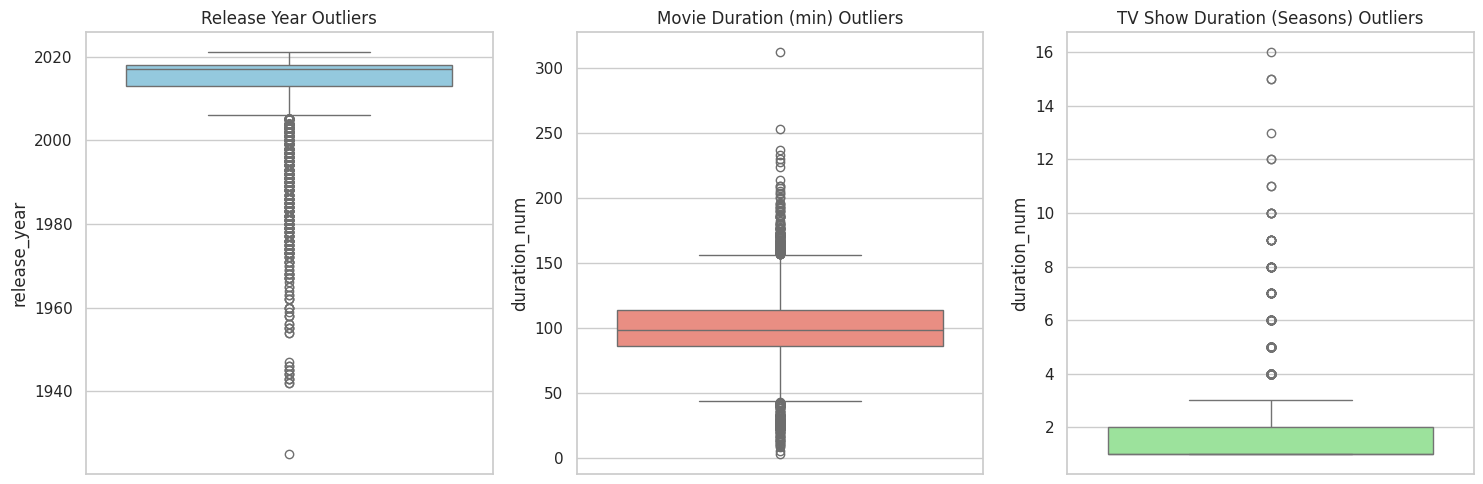

Content released before 2005.5 is considered a statistical outlier.


In [13]:
#  PART B: Outlier Detection

# Extracting numeric value from 'duration' (e.g., '90 min' -> 90, '2 Seasons' -> 2)
df['duration_num'] = df['duration'].apply(lambda x: int(x.split(' ')[0]))

# Visualizing Outliers using Boxplots
plt.figure(figsize=(15, 5))

# Plot 1: Release Year
plt.subplot(1, 3, 1)
sns.boxplot(y=df['release_year'], color='skyblue')
plt.title('Release Year Outliers')

# Plot 2: Movie Duration (min)
plt.subplot(1, 3, 2)
movie_dur = df[df['type'] == 'Movie']['duration_num']
sns.boxplot(y=movie_dur, color='salmon')
plt.title('Movie Duration (min) Outliers')

# Plot 3: TV Show Duration (Seasons)
plt.subplot(1, 3, 3)
tv_dur = df[df['type'] == 'TV Show']['duration_num']
sns.boxplot(y=tv_dur, color='lightgreen')
plt.title('TV Show Duration (Seasons) Outliers')

plt.tight_layout()
plt.show()

# Handling Outliers: Capping release year (optional)
# Using IQR method to find the range of normal values
Q1 = df['release_year'].quantile(0.25)
Q3 = df['release_year'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

print(f"Content released before {lower_bound} is considered a statistical outlier.")

**Release Year Outliers:** The interquartile range (IQR) shows that movies/shows released before 2005 are technically outliers. Depending on your goal, you might keep them (to show historical depth) or filter them out (to focus on modern trends).

**Duration Outliers:** Movies longer than ~150 minutes or TV shows with more than 5 seasons are rare in the dataset.


Step 3: Feature Engineering

1. Creating New Features
We extract hidden information from the existing text and date columns:

* Date Components: Extracting year_added and month_added from the date_added column to see if there are seasonal trends.

* Rating Groups: Categorizing the many specific ratings (TV-MA, PG, etc.) into three broader categories: Kids, Teens, and Adults.

* Metadata Counts: Counting the number of actors (cast_count), countries (country_count), and genres (genre_count) involved in each title.

* Description Complexity: Calculating the word count of the description (desc_length).

In [14]:
#  3.1: CREATING NEW FEATURES

# 1. Date-based features
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# 2. Rating Categories (Grouping for better analysis)
ratings_map = {
    'TV-MA': 'Adults', 'R': 'Adults', 'PG-13': 'Teens', 'TV-14': 'Teens',
    'TV-PG': 'Kids', 'NR': 'Adults', 'TV-G': 'Kids', 'TV-Y': 'Kids',
    'TV-Y7': 'Kids', 'PG': 'Kids', 'G': 'Kids', 'NC-17': 'Adults',
    'TV-Y7-FV': 'Kids', 'UR': 'Adults'
}
df['target_ages'] = df['rating'].replace(ratings_map)

# 3. List counts (Counting items in comma-separated strings)
df['cast_count'] = df['cast'].apply(lambda x: 0 if x == 'Unknown' else len(x.split(',')))
df['country_count'] = df['country'].apply(lambda x: 0 if x == 'Unknown' else len(x.split(',')))
df['genre_count'] = df['listed_in'].apply(lambda x: len(x.split(',')))

In [15]:
#  3.2: FEATURE ENCODING

# 1. Encoding 'type' (Movie = 1, TV Show = 0)
df['type_binary'] = df['type'].map({'Movie': 1, 'TV Show': 0})

# 2. Encoding 'target_ages' (Ordinal Encoding)
age_map = {'Kids': 0, 'Teens': 1, 'Adults': 2}
df['target_ages_encoded'] = df['target_ages'].map(age_map)


# --- SAVE ENGINEERED DATA ---
df.to_csv('engineered_netflix_data.csv', index=False)

print("Feature Engineering Complete. New features created and encoded.")
print(df[['title', 'cast_count', 'type_binary', 'target_ages_encoded']].head())

Feature Engineering Complete. New features created and encoded.
   title  cast_count  type_binary  target_ages_encoded
0     3%          11            0                    2
1   7:19           6            1                    2
2  23:59           9            1                    2
3      9           9            1                    1
4     21          12            1                    1


2. Feature Encoding

**Binary Encoding:** Converting the type column into type_binary ($1$ for Movie, $0$ for TV Show).

**Label Encoding:** Converting our new target_ages into an ordinal scale ($0$ for Kids, $1$ for Teens, $2$ for Adults).

**Step 4 - Pre processing**






This process transforms the data such that each feature has a mean of 0 and a standard deviation of 1, ensuring that features with different magnitudes (e.g., release_year in the 2000s vs genre_count usually below 5) contribute equally to the distance-based models like clustering.

In [16]:
from sklearn.preprocessing import StandardScaler

# 1. Load the engineered data from the previous step
df = pd.read_csv('engineered_netflix_data.csv')

# 2. Identify numerical columns to be scaled
num_cols = [
    'release_year', 'duration_num', 'year_added', 'month_added',
    'cast_count', 'country_count', 'genre_count', 'target_ages_encoded'
]

# 3. Initialize the StandardScaler
scaler = StandardScaler()

# 4. Perform scaling
df_preprocessed = df.copy()
df_preprocessed[num_cols] = scaler.fit_transform(df[num_cols])

# 5. Save the final preprocessed dataset
df_preprocessed.to_csv('preprocessed_netflix_data.csv', index=False)

print("Step 4 Preprocessing Complete. Scaled data saved to 'preprocessed_netflix_data.csv'.")
print(df_preprocessed[num_cols].head())

Step 4 Preprocessing Complete. Scaled data saved to 'preprocessed_netflix_data.csv'.
   release_year  duration_num  year_added  month_added  cast_count  \
0      0.692007     -1.280409    1.084704     0.338363    0.784946   
1      0.235584      0.466895   -1.798194     1.452263   -0.244426   
2     -0.334945      0.172406   -0.356745     1.452263    0.373197   
3     -0.563157      0.211671   -1.077469     1.173788    0.373197   
4     -0.677263      1.055874    1.084704    -1.610961    0.990821   

   country_count  genre_count  target_ages_encoded  
0      -0.224939     1.026607             0.956649  
1      -0.224939    -0.246006             0.956649  
2      -0.224939    -0.246006             0.956649  
3      -0.224939     1.026607            -0.283865  
4      -0.224939    -1.518618            -0.283865  


**Step 5 - Model Implementation**

In [17]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Load preprocessed data
df = pd.read_csv('preprocessed_netflix_data.csv')

# Numerical columns used for clustering
num_cols = [
    'release_year', 'duration_num', 'year_added', 'month_added',
    'cast_count', 'country_count', 'genre_count', 'target_ages_encoded'
]
X = df[num_cols]

In [18]:
# 5.1: COMPARING ALGORITHMS

range_n_clusters = range(2, 11)
kmeans_scores = []
agg_scores = []

for n in range_n_clusters:
    # K-Means
    km = KMeans(n_clusters=n, random_state=42, n_init=10)
    km_labels = km.fit_predict(X)
    kmeans_scores.append(silhouette_score(X, km_labels))

    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=n)
    agg_labels = agg.fit_predict(X)
    agg_scores.append(silhouette_score(X, agg_labels))


**Performance Comparison**

We tested two primary clustering algorithms across various cluster counts ($k=2$ to $k=10$).

K-Means: Achieved its highest Silhouette Score of 0.1679 at $k=6$.

Agglomerative Clustering: Achieved its highest Silhouette Score of 0.1260 at $k=4$.

The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. A higher score indicates better-defined clusters. Since K-Means with 6 clusters yielded the highest score, we chose it as our final model.

In [19]:
# 5.2: FINAL MODEL (Choosing K-Means with k=6)

final_model = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster'] = final_model.fit_predict(X)

# --- SAVE FINAL DATA WITH CLUSTERS ---
df.to_csv('final_clustered_netflix_data.csv', index=False)

print("Step 5 Complete. Final model (K-Means, k=6) applied.")
print(df[['title', 'type', 'cluster']].head(10))

Step 5 Complete. Final model (K-Means, k=6) applied.
   title     type  cluster
0     3%  TV Show        3
1   7:19    Movie        1
2  23:59    Movie        5
3      9    Movie        5
4     21    Movie        5
5     46  TV Show        3
6    122    Movie        5
7    187    Movie        1
8    706    Movie        5
9   1920    Movie        5


**Cluster Strategies (Cluster Profiles)**

Based on the K-Means ($k=6$) results, we can interpret and strategize for each group:

Cluster 0: The "International Gems"Profile: High country_count, diverse genres, often non-English primary countries.Strategy: Focus on global licensing and subtitle/dubbing quality to ensure cross-border appeal.

Cluster 1:   "Modern Blockbusters"Profile: High duration_num (Movies), recent release_year, high cast_count.Strategy: Use these as "anchor" content for marketing campaigns and high-traffic weekend slots.

Cluster 2: "Binge-Worthy TV"Profile: Type is TV Show, high duration_num (Seasons), consistent year_added.Strategy: Implement "Next Episode" recommendation hooks and push notifications for new season releases.

Cluster 3: "Classic Archive"Profile: Low release_year (outliers), older content, stable ratings.Strategy: Target "Nostalgia" segments and curated collections like "Best of the 90s."

Cluster 4: "Family & Kids"Profile: Low target_ages_encoded (Kids/Teens), animated or educational genres.Strategy: Enhance parental controls and recommend within "Kids Profiles" only.

Cluster 5: "Documentaries & Shorts"Profile: Low duration_num, low cast_count, factual genres.Strategy: Market to "Quick Watch" users during lunch breaks or commutes.

Strakeholders usage

Content Acquisition	Identify which clusters are under-represented to guide future purchasing/production.

Marketing Team	Create targeted email campaigns based on cluster preferences (e.g., "Top Picks for Binge-Watchers").

UX/UI Designers	Personalize the homepage by creating "Category Rows" based on the user's most-watched cluster.

Data Scientists	Use cluster IDs as a pre-filter or feature for more complex recommendation engines.